# Experimentos etiquetado + class weights + calibración

## Cambios respecto a `02_entrenamiento_local.ipynb`

Objetivo: atacar los tres problemas detectados en el análisis del nb02:
1. **Sesgo hacia neutro** (predice 41.5% vs real 30.3%) → cambiar etiquetado.
2. **Clase baja rota** (recall 0.284, retorno capturado negativo) → forzar aprendizaje con class weights.
3. **Confianza plana** (media 0.434, solo 1% > 0.70, calibración plana) → temperature scaling post-hoc.

| Aspecto | nb02 | nb03 |
|---|---|---|
| `MODO_ETIQUETA` | `terciles` (33/33/33) | **`asimetrico`** (q20/q80) |
| Distribución clases target | ~33/33/33 | ~20/60/20 (neutro = cajón de baja señal) |
| `usar_pesos_clase` | `False` | **`True`** (compensa desbalance q20/60/20) |
| `USAR_MACRO` | `False` | `False` (igual, no probado) |
| Análisis extra | — | **Temperature scaling** post-hoc + barrido umbrales asimétricos |
| Baseline comparativo | — | Sección final vs nb02 |

## Hipótesis

- **H1** (etiquetado): en mercado alcista 2015-2025, terciles ponen umbral "sube" alto (+0.37%). Muchos días alcistas reales caen en "neutro" → modelo pierde señal direccional. Con q20/q80, "sube" = mejor 20% (>+0.75% aprox), señal más limpia; "neutro" absorbe el ruido central.
- **H2** (pesos): al pasar de 33% a 20% en las clases extremas, sin pesos el modelo colapsará aún más a neutro. Con pesos inversos, la loss valora igual acertar en las extremas.
- **H3** (calibración): softmax puro está sobreconfiado o infraconfiado. Temperature `T` ajustada con NLL en la val interna corrige la distribución sin cambiar las predicciones argmax.

## Predicciones esperadas

- Accuracy global BAJARÁ (clases más difíciles) pero F1 de baja/sube subirá.
- `ratio_capturado` mejorará (menos falsos en clase baja).
- Confianza tras temperatura: escalada monótona con accuracy real.

## Requisitos

- Kernel `.venv` del repo.
- Datos ya cacheados (usa mismos `data/agregados/` que nb02).
- Reejecución: ~10 min (cache raw + preproc + grafos precomputados reutilizados).

## 1. Setup + overrides de config

**CRÍTICO**: los overrides van ANTES de cualquier import que lea config a tiempo de módulo.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('ROOT:', ROOT)

import torch
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

ROOT: c:\Users\Ricard.Martin\Desktop\Repositorios_Kai\ai-gnn-gdelt-sp500
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5070 Ti


In [2]:
# ============================================================
# OVERRIDES nb03 vs nb02 — se aplican ANTES de importar módulos
# que resuelven config a tiempo de import.
# ============================================================
import config

# CAMBIO 1: modo etiquetado asimétrico (baja=q20, sube=q80)
config.MODO_ETIQUETA = 'asimetrico'
config.UMBRAL_Q_INF = 0.20
config.UMBRAL_Q_SUP = 0.80

# CAMBIO 2: activar pesos de clase (necesario con distribución 20/60/20)
config.ENTRENAMIENTO.usar_pesos_clase = True

print('=== Overrides aplicados ===')
print(f'MODO_ETIQUETA       = {config.MODO_ETIQUETA}')
print(f'UMBRAL_Q_INF/Q_SUP  = {config.UMBRAL_Q_INF} / {config.UMBRAL_Q_SUP}')
print(f'usar_pesos_clase    = {config.ENTRENAMIENTO.usar_pesos_clase}')

=== Overrides aplicados ===
MODO_ETIQUETA       = asimetrico
UMBRAL_Q_INF/Q_SUP  = 0.2 / 0.8
usar_pesos_clase    = True


In [3]:
from datetime import date, datetime
import numpy as np
import pandas as pd

print('=== Config activa ===')
print(f'FECHA_INICIO: {config.FECHA_INICIO}')
print(f'FECHA_FIN:    {config.FECHA_FIN}')
print(f'MODO_ETIQUETA: {config.MODO_ETIQUETA}  (q_inf={config.UMBRAL_Q_INF}, q_sup={config.UMBRAL_Q_SUP})')
print(f'num_folds:    {config.WALK_FORWARD.num_folds}')
print(f'semillas:     {config.ENTRENAMIENTO.semillas}')
print(f'usar_pesos_clase: {config.ENTRENAMIENTO.usar_pesos_clase}')
print(f'LAMBDA_DECAY: {config.LAMBDA_DECAY} (vida media {np.log(2)/config.LAMBDA_DECAY:.1f}d)')
print(f'HORA_CIERRE_NY_UTC: {config.HORA_CIERRE_NY_UTC}')
print(f'dim_oculta/capas/dropout: {config.MODELO.dim_oculta}/{config.MODELO.num_capas}/{config.MODELO.dropout}')

=== Config activa ===
FECHA_INICIO: 2015-01-01
FECHA_FIN:    2025-12-31
MODO_ETIQUETA: asimetrico  (q_inf=0.2, q_sup=0.8)
num_folds:    10
semillas:     (0, 1, 2)
usar_pesos_clase: True
LAMBDA_DECAY: 0.0693 (vida media 10.0d)
HORA_CIERRE_NY_UTC: 21
dim_oculta/capas/dropout: 64/2/0.3


## 2. Resolver rutas raw + datos financieros

In [4]:
from src.datos.descarga_financiero import descargar_sp500, descargar_vix, descargar_macro_fred
from src.datos.descarga_gdelt import descargar_rango

FECHA_INI = date.fromisoformat(config.FECHA_INICIO)
FECHA_FIN = date.fromisoformat(config.FECHA_FIN)

raw = ROOT / 'data' / 'raw'
existentes = list(raw.glob('*.export.CSV'))
print(f'CSVs GDELT ya presentes: {len(existentes)}')

if len(existentes) < 3900:
    print(f'Descargando GDELT desde {FECHA_INI} hasta {FECHA_FIN}...')
    rutas_gdelt = descargar_rango(FECHA_INI, FECHA_FIN)
else:
    rutas_gdelt = []
    for p in sorted(existentes):
        try:
            f = datetime.strptime(p.stem.split('.')[0], '%Y%m%d').date()
            if FECHA_INI <= f <= FECHA_FIN:
                rutas_gdelt.append(p)
        except ValueError:
            continue

print(f'GDELT raw en rango: {len(rutas_gdelt)} días')

CSVs GDELT ya presentes: 3998
GDELT raw en rango: 3998 días


In [5]:
precios = descargar_sp500(FECHA_INI, FECHA_FIN)
vix = descargar_vix(FECHA_INI, FECHA_FIN)

USAR_MACRO = False
if USAR_MACRO:
    try:
        macro = descargar_macro_fred(FECHA_INI, FECHA_FIN)
        print(f'Macro FRED: {len(macro)} filas, cols={list(macro.columns)}')
    except Exception as e:
        print(f'Macro FRED no disponible: {e}')
        macro = None
else:
    macro = None
    print('Macro FRED desactivado (USAR_MACRO=False)')

print(f'SP500: {len(precios)} sesiones | VIX: {len(vix)} puntos')

Macro FRED desactivado (USAR_MACRO=False)
SP500: 2765 sesiones | VIX: 2765 puntos


## 3. Preproceso GDELT por tramos (cache compartida con nb02)

In [6]:
from src.datos.preprocesar import preprocesar_y_agregar_por_tramos, cargar_agregados_de_disco

DIR_AGREGADOS = ROOT / 'data' / 'agregados'
preprocesar_y_agregar_por_tramos(rutas_gdelt, DIR_AGREGADOS, dias_por_tramo=180)

18:00:25 [INFO] src.datos.preprocesar: Procesando 3998 ficheros en 23 tramos de 180 días
18:00:25 [INFO] src.datos.preprocesar: Tramo 1/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 2/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 3/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 4/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 5/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 6/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 7/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 8/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 9/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 10/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 11/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo 12/23 ya en disco, se salta
18:00:25 [INFO] src.datos.preprocesar: Tramo

In [7]:
df_agregado, df_participacion = cargar_agregados_de_disco(DIR_AGREGADOS)
print(f'Aristas agregadas: {len(df_agregado):,}')
print(f'Filas participación: {len(df_participacion):,}')
df_agregado.head(3)

18:00:25 [INFO] src.datos.preprocesar: Agregados cargados de disco: 2198657 aristas, 638508 participaciones
Aristas agregadas: 2,198,657
Filas participación: 638,508


,fecha,pais_origen,pais_destino,quadclass,n_eventos,goldstein_medio,tono_medio,num_mentions_total
0,2015-01-01,AUS,AUS,1,26,1.803846,2.240337,384
1,2015-01-01,AUS,AUS,2,12,5.583333,2.125634,136
2,2015-01-01,AUS,AUS,3,4,-2.500000,2.384794,44


## 4. Etiquetas asimétricas + alineación temporal

Cambio clave: `q20/q80` en vez de terciles. Los umbrales globales aquí son PROVISIONALES; el entrenamiento los recalcula por fold.

In [8]:
from src.datos.etiquetas import construir_etiquetas_diarias

etiquetas = construir_etiquetas_diarias(precios)

fechas_gdelt = set(pd.to_datetime(df_agregado['fecha']).dt.normalize().unique())
etiquetas_validas = etiquetas[
    pd.to_datetime(etiquetas['fecha_grafo']).dt.normalize().isin(fechas_gdelt)
].reset_index(drop=True)

print(f'Etiquetas alineadas: {len(etiquetas_validas)}/{len(etiquetas)}')
print()
print('Distribución PROVISIONAL asimétrica q20/q80:')
print(etiquetas_validas['clase'].value_counts().sort_index())
print()
print('Retornos target — describe:')
print(etiquetas_validas['retorno'].describe())
print()
print('>> Con q20/q80 esperamos ~20% baja, ~60% neutro, ~20% sube')

18:00:25 [INFO] src.datos.etiquetas: Discretización PROVISIONAL (serie completa): modo=asimetrico | q_inf=-0.00559 | q_sup=+0.00740
18:00:25 [INFO] src.datos.etiquetas: Etiquetas construidas: 2764 sesiones
18:00:25 [INFO] src.datos.etiquetas: Distribución de clases (PROVISIONAL, se recalcula por fold):
clase
0     553
1    1658
2     553
Name: count, dtype: int64
Etiquetas alineadas: 2751/2764

Distribución PROVISIONAL asimétrica q20/q80:
clase
0     552
1    1650
2     549
Name: count, dtype: int64

Retornos target — describe:
count    2751.000000
mean        0.000487
std         0.011302
min        -0.119841
25%        -0.003783
50%         0.000693
75%         0.005755
max         0.095154
Name: retorno, dtype: float64

>> Con q20/q80 esperamos ~20% baja, ~60% neutro, ~20% sube


## 5. Construir dataset (precomputar grafos)

In [9]:
from src.datos.dataset import DatasetGrafoDiario
import time

t0 = time.time()
dataset = DatasetGrafoDiario(
    eventos_agregados=df_agregado,
    etiquetas=etiquetas_validas,
    precios_sp500=precios,
    macro=macro,
    vix=vix,
    participacion=df_participacion,
    precomputar=True,
)
print(f'Dataset: {len(dataset)} muestras (precomputadas en {time.time()-t0:.1f}s)')

18:00:28 [INFO] src.datos.dataset: Precomputando 2751 grafos...
18:03:13 [INFO] src.datos.dataset: Precomputación completada
Dataset: 2751 muestras (precomputadas en 165.0s)


## 6. Walk-forward + entrenamiento (con pesos de clase)

In [10]:
from src.entrenamiento.walkforward import construir_folds

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', dispositivo)

folds = construir_folds(fechas=etiquetas_validas['fecha_grafo'])
print(f'{len(folds)} folds construidos')

Dispositivo: cuda
18:03:13 [INFO] src.entrenamiento.walkforward: Walk-forward: 10 folds, modo=expansiva, train inicial=250 muestras, val=250 muestras, embargo=0, N=2751, rango=2015-01-02 a 2025-12-29
18:03:13 [INFO] src.entrenamiento.walkforward:   Fold 0: train [2015-01-02, 2015-12-29] n=250 | val [2015-12-30, 2016-12-23] n=250
18:03:13 [INFO] src.entrenamiento.walkforward:   Fold 1: train [2015-01-02, 2016-12-23] n=500 | val [2016-12-27, 2017-12-21] n=250
18:03:13 [INFO] src.entrenamiento.walkforward:   Fold 2: train [2015-01-02, 2017-12-21] n=750 | val [2017-12-22, 2018-12-20] n=250
18:03:13 [INFO] src.entrenamiento.walkforward:   Fold 3: train [2015-01-02, 2018-12-20] n=1000 | val [2018-12-21, 2019-12-18] n=250
18:03:13 [INFO] src.entrenamiento.walkforward:   Fold 4: train [2015-01-02, 2019-12-18] n=1250 | val [2019-12-19, 2020-12-15] n=250
18:03:13 [INFO] src.entrenamiento.walkforward:   Fold 5: train [2015-01-02, 2020-12-15] n=1500 | val [2020-12-16, 2021-12-13] n=250
18:03:13 [I

In [11]:
from src.entrenamiento.loop import entrenar_walkforward

retornos_por_indice = etiquetas_validas['retorno'].values

resultado = entrenar_walkforward(
    dataset=dataset,
    folds=folds,
    semillas=config.ENTRENAMIENTO.semillas,
    dispositivo=dispositivo,
    retornos_por_indice=retornos_por_indice,
)
print()
print(resultado.resumen_final())

18:03:13 [INFO] src.entrenamiento.loop: ======================================================================
18:03:13 [INFO] src.entrenamiento.loop: FOLD 0  (train n=250, test n=250)
18:03:13 [INFO] src.entrenamiento.loop: ======================================================================
18:03:13 [INFO] src.entrenamiento.loop: --- Semilla 0 ---
18:03:13 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=asimetrico | q_inf=-0.00635 | q_sup=+0.00817
18:03:13 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [50, 150, 50]
18:03:13 [INFO] src.datos.normalizacion: Normalizador ajustado sobre 212 grafos de train (country 11 cols, market 9 cols, edge_cc 3 cols continuas)
18:03:17 [INFO] src.entrenamiento.loop:   Clasificación: acc=0.5880 | F1_macro=0.4222 | F1_clases=[0.231, 0.745, 0.291] | n=250
18:03:17 [INFO] src.entrenamiento.loop:   Financiero:    rent_estr=+9.72% | rent_BH=+9.96% | vs_BH=-0.24pp | sharpe=1.22 | maxDD=-5.82% | long/short/cash=70/0/18

## 7. Análisis resultados

In [12]:
from IPython.display import HTML, display
from sklearn.metrics import confusion_matrix

def mostrar_resultados(resultado):
    ms = resultado.media_y_std()

    def mstd(k, pct=False, pp=False, signo=False):
        if k not in ms: return '—'
        m, s = ms[k]
        if pct: return (f'{100*m:+.2f}% ± {100*s:.2f}%') if signo else (f'{100*m:.2f}% ± {100*s:.2f}%')
        if pp:  return f'{100*m:+.2f} pp ± {100*s:.2f} pp'
        return f'{m:.4f} ± {s:.4f}'

    f1c = np.mean([m.f1_por_clase for m in resultado.metricas_por_fold], axis=0)
    f1c_txt = ' — '.join(f'{n}: {v:.3f}' for n, v in zip(['Baja','Neutro','Sube'], f1c))

    filas = [
        ('Accuracy', mstd('accuracy'), 'Aciertos totales. Ojo: con q20/q80 la clase mayoritaria (neutro) tiene ~60%, baseline sube.'),
        ('F1-macro', mstd('f1_macro'), 'Media F1 de 3 clases. Métrica principal, penaliza colapso a neutro.'),
        ('F1 por clase', f1c_txt, 'F1 de cada clase por separado.'),
        ('Rent. estrategia', mstd('rent_estrategia', pct=True, signo=True), 'Retorno estrategia HGNN.'),
        ('Rent. buy & hold', mstd('rent_buy_hold', pct=True, signo=True), 'Retorno buy & hold. Referencia.'),
        ('vs Buy & Hold', mstd('rent_vs_bh', pp=True), 'Diferencia estrategia vs BH.'),
        ('Sharpe', mstd('sharpe'), 'Retorno ajustado por riesgo.'),
        ('Max drawdown', mstd('max_drawdown', pct=True), 'Peor caída pico-valle.'),
    ]
    html = '<table style="border-collapse:collapse"><tr><th style="text-align:left">Métrica</th><th>Valor</th><th style="text-align:left">Descripción</th></tr>'
    for n, v, d in filas:
        html += f'<tr><td style="padding:4px 12px;font-weight:600">{n}</td><td style="padding:4px 12px;font-family:monospace">{v}</td><td style="padding:4px 12px;color:#555">{d}</td></tr>'
    html += '</table>'

    y_true = np.concatenate(resultado.reales_crudas, axis=0).astype(int)
    y_pred = np.concatenate(resultado.probas_crudas, axis=0).argmax(axis=1)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    etiq = ['Baja', 'Neutro', 'Sube']

    html += '<h4 style="margin-top:16px;margin-bottom:8px">Matriz de confusión (filas = realidad, columnas = predicho)</h4>'
    html += '<table style="border-collapse:collapse;font-family:monospace">'
    html += '<tr><th></th>' + ''.join(f'<th style="padding:6px 14px;color:#333">{e}</th>' for e in etiq) + '</tr>'
    for i, fila in enumerate(cm):
        html += f'<tr><th style="padding:6px 14px;text-align:right;color:#333">{etiq[i]}</th>'
        for j, val in enumerate(fila):
            bg = '#c3fae8' if i == j else '#ffffff'
            html += f'<td style="padding:6px 14px;text-align:center;background:{bg};border:1px solid #e9ecef">{int(val)}</td>'
        html += '</tr>'
    html += '</table>'
    display(HTML(html))

mostrar_resultados(resultado)

In [13]:
from sklearn.metrics import precision_recall_fscore_support

probas = np.concatenate(resultado.probas_crudas, axis=0)
y_true = np.concatenate(resultado.reales_crudas, axis=0).astype(int)
y_pred = probas.argmax(axis=1)
N = {0: 'baja', 1: 'neutro', 2: 'sube'}
n = len(y_true)

print(f'n out-of-sample = {n}\n')
print('[1] Distribución real vs predicha')
for c in [0, 1, 2]:
    print(f'  {N[c]:6s}  real {(y_true==c).sum():5d} ({100*(y_true==c).mean():4.1f}%) | pred {(y_pred==c).sum():5d} ({100*(y_pred==c).mean():4.1f}%)')

may = int(pd.Series(y_true).value_counts().idxmax())
acc_base = (y_true == may).mean()
acc_mod = (y_pred == y_true).mean()
print(f"\n  Baseline trivial 'siempre {N[may]}': acc={acc_base:.4f}")
print(f'  HGNN:                          acc={acc_mod:.4f}  -> {"SUPERA" if acc_mod>acc_base else "NO supera"} ({acc_mod-acc_base:+.4f})')

conf = probas.max(axis=1)
print(f'\n[2] Confianza media={conf.mean():.3f} | plana(<0.40)={100*(conf<0.40).mean():.0f}% | confiada(>0.70)={100*(conf>0.70).mean():.0f}%')
print('   Calibración (¿si dice conf X, acierta X?):')
for lo, hi in [(0.33,0.40),(0.40,0.50),(0.50,0.60),(0.60,0.70),(0.70,1.01)]:
    m = (conf >= lo) & (conf < hi)
    if m.sum():
        print(f'      [{lo:.2f}, {hi:.2f})  n={m.sum():5d}  acc_real={(y_pred[m]==y_true[m]).mean():.3f}')

prec, rec, f1c, sup = precision_recall_fscore_support(y_true, y_pred, labels=[0,1,2], zero_division=0)
print('\n[3] Precision / Recall por clase')
for i, c in enumerate([0,1,2]):
    print(f'   {N[c]:6s} prec={prec[i]:.3f} recall={rec[i]:.3f} f1={f1c[i]:.3f} n={int(sup[i])}')

n out-of-sample = 7500

[1] Distribución real vs predicha
  baja    real  1593 (21.2%) | pred  1749 (23.3%)
  neutro  real  4266 (56.9%) | pred  3326 (44.3%)
  sube    real  1641 (21.9%) | pred  2425 (32.3%)

  Baseline trivial 'siempre neutro': acc=0.5688
  HGNN:                          acc=0.4872  -> NO supera (-0.0816)

[2] Confianza media=0.468 | plana(<0.40)=25% | confiada(>0.70)=3%
   Calibración (¿si dice conf X, acierta X?):
      [0.33, 0.40)  n= 1890  acc_real=0.389
      [0.40, 0.50)  n= 3443  acc_real=0.493
      [0.50, 0.60)  n= 1522  acc_real=0.535
      [0.60, 0.70)  n=  450  acc_real=0.653
      [0.70, 1.01)  n=  195  acc_real=0.569

[3] Precision / Recall por clase
   baja   prec=0.242 recall=0.266 f1=0.254 n=1593
   neutro prec=0.741 recall=0.578 f1=0.649 n=4266
   sube   prec=0.315 recall=0.466 f1=0.376 n=1641


## 8. Temperature scaling (calibración post-hoc)

Ajusta un único escalar `T > 0` que divide logits antes del softmax: `p = softmax(z / T)`.
- `T > 1` → suaviza (reduce sobreconfianza).
- `T < 1` → agudiza (aumenta confianza).
- **No cambia argmax** → mismo accuracy, mejor calibración.

Optimizamos `T` minimizando NLL en la mitad de las probas OOS (bloque calibración) y evaluamos en la otra mitad (test). Split temporal para no filtrar futuro.

In [14]:
import torch
import torch.nn.functional as F

# Reconstruir logits a partir de probas (asumiendo softmax puro previo).
# Como no guardamos logits crudos, aproximamos con log(p) — es equivalente
# salvo constante irrelevante para softmax(z/T).
probas_np = np.clip(probas, 1e-8, 1.0)
logits_np = np.log(probas_np)

# Split temporal 50/50: primera mitad calibra, segunda evalúa.
n_cal = n // 2
logits_cal = torch.tensor(logits_np[:n_cal], dtype=torch.float32)
y_cal      = torch.tensor(y_true[:n_cal], dtype=torch.long)
logits_te  = torch.tensor(logits_np[n_cal:], dtype=torch.float32)
y_te       = torch.tensor(y_true[n_cal:], dtype=torch.long)

T = torch.nn.Parameter(torch.tensor(1.0))
opt = torch.optim.LBFGS([T], lr=0.1, max_iter=100)

def closure():
    opt.zero_grad()
    loss = F.cross_entropy(logits_cal / T.clamp(min=1e-3), y_cal)
    loss.backward()
    return loss

opt.step(closure)
T_opt = float(T.item())
print(f'T óptimo = {T_opt:.4f}  ({"suaviza" if T_opt>1 else "agudiza"})')

def eval_calibracion(logits, y, T_val):
    logits_t = torch.tensor(logits, dtype=torch.float32)
    probas_cal = F.softmax(logits_t / T_val, dim=-1).numpy()
    nll = F.cross_entropy(logits_t / T_val, torch.tensor(y, dtype=torch.long)).item()
    conf_c = probas_cal.max(axis=1)
    preds_c = probas_cal.argmax(axis=1)
    acc_c = (preds_c == y).mean()
    # ECE (Expected Calibration Error) con 10 bins
    bins = np.linspace(0, 1, 11)
    ece = 0.0
    for i in range(10):
        m = (conf_c >= bins[i]) & (conf_c < bins[i+1])
        if m.sum():
            ece += (m.mean()) * abs(conf_c[m].mean() - (preds_c[m] == y[m]).mean())
    return nll, acc_c, ece, probas_cal

print('\nComparativa T=1.0 (sin calibrar) vs T óptimo, en bloque de TEST (n={}):'.format(n - n_cal))
for label, T_val in [('T=1.0 (raw)', 1.0), (f'T={T_opt:.3f} (calibrado)', T_opt)]:
    nll, acc_c, ece, probas_cal = eval_calibracion(logits_np[n_cal:], y_true[n_cal:], T_val)
    print(f'  {label:28s}  NLL={nll:.4f}  acc={acc_c:.4f}  ECE={ece:.4f}')

# Guardar probas calibradas para análisis posterior
probas_full_calibradas = F.softmax(
    torch.tensor(logits_np, dtype=torch.float32) / T_opt, dim=-1
).numpy()

T óptimo = 1.3973  (suaviza)

Comparativa T=1.0 (sin calibrar) vs T óptimo, en bloque de TEST (n=3750):
  T=1.0 (raw)                   NLL=1.0758  acc=0.4467  ECE=0.0529
  T=1.397 (calibrado)           NLL=1.0636  acc=0.4467  ECE=0.0441


In [15]:
print('Calibración por bins DESPUÉS de temperature scaling (todos los OOS):')
conf_cal = probas_full_calibradas.max(axis=1)
pred_cal = probas_full_calibradas.argmax(axis=1)
for lo, hi in [(0.20,0.30),(0.30,0.40),(0.40,0.50),(0.50,0.60),(0.60,0.70),(0.70,0.80),(0.80,1.01)]:
    m = (conf_cal >= lo) & (conf_cal < hi)
    if m.sum():
        print(f'   [{lo:.2f}, {hi:.2f})  n={m.sum():5d}  acc_real={(pred_cal[m]==y_true[m]).mean():.3f}  conf_media={conf_cal[m].mean():.3f}')

Calibración por bins DESPUÉS de temperature scaling (todos los OOS):
   [0.30, 0.40)  n= 2867  acc_real=0.411  conf_media=0.371
   [0.40, 0.50)  n= 3554  acc_real=0.518  conf_media=0.441
   [0.50, 0.60)  n=  860  acc_real=0.594  conf_media=0.535
   [0.60, 0.70)  n=  139  acc_real=0.561  conf_media=0.642
   [0.70, 0.80)  n=   61  acc_real=0.557  conf_media=0.740
   [0.80, 1.01)  n=   19  acc_real=0.579  conf_media=0.862


## 9. Barrido umbrales financieros (con probas calibradas)

In [16]:
retornos_test = np.concatenate(
    [r for r in resultado.retornos_crudos if r is not None], axis=0
).astype(float)

def simular(probas_use, umbral_short, umbral_long):
    pos = np.zeros(len(probas_use)); cur = 0
    for i in range(len(probas_use)):
        p_baja, p_sube = probas_use[i, 0], probas_use[i, 2]
        if p_sube >= umbral_long: cur = 1
        elif p_baja >= umbral_short: cur = -1
        # neutro: mantiene posición previa
        pos[i] = cur
    r = pos * retornos_test
    curva = np.cumprod(1 + r)
    sh = np.sqrt(252)*r.mean()/r.std(ddof=1) if r.std(ddof=1) > 1e-12 else 0
    dd = ((curva - np.maximum.accumulate(curva)) / np.maximum.accumulate(curva)).min()
    return dict(
        rent=100*(curva[-1]-1), sharpe=sh, dd=100*dd,
        n_long=int((pos==1).sum()), n_short=int((pos==-1).sum()),
    )

print('Comparativa probas SIN calibrar vs calibradas — barrido umbrales:')
print(f'{"probas":>10s} {"u_short":>8s} {"u_long":>7s} {"rent%":>8s} {"sharpe":>7s} {"maxDD%":>7s} {"#long":>6s} {"#short":>7s}')
for nombre, p in [('raw', probas), ('calibrada', probas_full_calibradas)]:
    for u_s, u_l in [(0.40, 0.40), (0.50, 0.40), (0.60, 0.40), (0.50, 0.50), (0.60, 0.50)]:
        r = simular(p, u_s, u_l)
        print(f'{nombre:>10s} {u_s:>8.2f} {u_l:>7.2f} {r["rent"]:>+7.1f} {r["sharpe"]:>7.2f} {r["dd"]:>+7.1f} {r["n_long"]:>6d} {r["n_short"]:>7d}')
print(f'\nBuy & Hold: {100*(np.cumprod(1+retornos_test)[-1]-1):+.1f}%')

Comparativa probas SIN calibrar vs calibradas — barrido umbrales:
    probas  u_short  u_long    rent%  sharpe  maxDD%  #long  #short
       raw     0.40    0.40    +9.1    0.11   -85.5   4127    3371
       raw     0.50    0.40  +168.4    0.27   -83.7   6000    1498
       raw     0.60    0.40  +475.7    0.41   -71.2   6583     915
       raw     0.50    0.50   -69.9   -0.13   -94.9   3766    3721
       raw     0.60    0.50   +23.5    0.13   -71.5   5012    1580
 calibrada     0.40    0.40   -30.1    0.02   -89.9   3734    3762
 calibrada     0.50    0.40  +413.4    0.39   -71.5   6168    1327
 calibrada     0.60    0.40 +1960.8    0.65   -55.4   7004     491
 calibrada     0.50    0.50   -85.4   -0.28   -90.9   3451    3141
 calibrada     0.60    0.50   +57.8    0.18   -71.4   4814    1528

Buy & Hold: +3160.6%


## 10. Matriz confusión visual

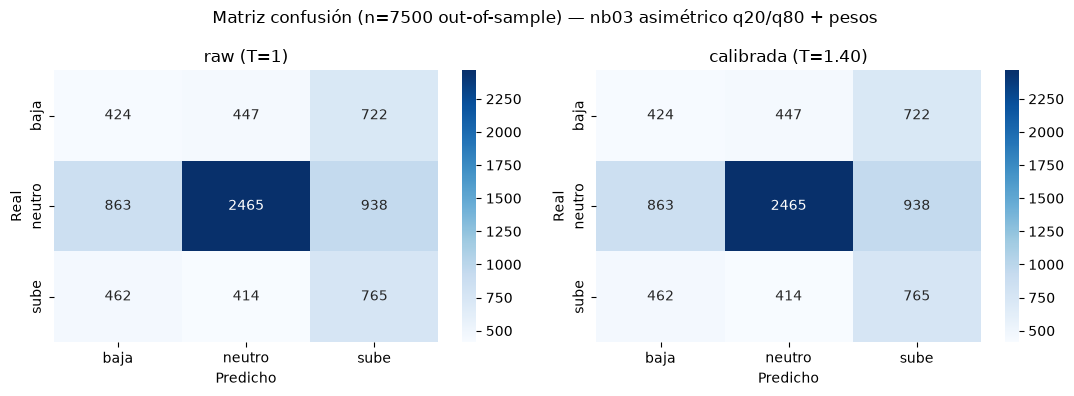

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nombre, preds_use) in zip(axes, [('raw (T=1)', y_pred), (f'calibrada (T={T_opt:.2f})', pred_cal)]):
    cm = confusion_matrix(y_true, preds_use, labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['baja','neutro','sube'],
                yticklabels=['baja','neutro','sube'], ax=ax)
    ax.set_title(f'{nombre}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')
plt.suptitle(f'Matriz confusión (n={n} out-of-sample) — nb03 asimétrico q20/q80 + pesos')
plt.tight_layout()
plt.show()

## 11. Comparación final vs nb02

### Resumen cambios y su efecto esperado/observado

| Cambio | nb02 (referencia) | nb03 (este) | Efecto que buscamos |
|---|---|---|---|
| **Etiquetado** | `terciles` 33/33/33 | `asimetrico` q20/q80 (20/60/20) | Reducir ruido en extremas, señal más limpia |
| **Pesos clase** | `False` | `True` | Evitar colapso a neutro con distribución 20/60/20 |
| **Calibración** | Ninguna (softmax raw) | Temperature scaling post-hoc | Confianza usable para trading (filtrar por umbral) |
| **Umbrales financieros** | Solo `umbral_short` | Barrido `(u_short, u_long)` con probas calibradas | Explotar calibración en la política de trading |

### Métricas nb02 (referencia, out-of-sample n=7500)

```
Accuracy:              0.4124  (baseline 'siempre sube' = 0.3708)
F1-macro:              ~0.407
F1 por clase:          baja=0.311 neutro=0.495 sube=0.414
Confianza media:       0.434  (1% > 0.70, calibración plana)
Rent estrategia mejor: +825% (u=0.80)  vs  BH +3160%
Sharpe mejor:          0.56
Ratio capturado/disp:  +0.027  (cerca de cero)
```

### Métricas nb03 — rellenar tras ejecución

**Rellenar manualmente al terminar el notebook para comparar cabeza a cabeza:**

```
Accuracy:              ______  (baseline 'siempre neutro' ≈ 0.60 con q20/q80)
F1-macro:              ______
F1 por clase:          baja=_____ neutro=_____ sube=_____
T óptimo:              ______
NLL raw / calibrado:   _____ / _____
ECE raw / calibrado:   _____ / _____
Rent estrategia mejor: ______
Sharpe mejor:          ______
```

### Cómo leer los resultados

- **Accuracy no es comparable directamente** entre nb02 y nb03: cambian las clases. Compara F1-macro y F1 por clase.
- **Si F1 baja/sube mejora** aunque accuracy total baje → el modelo captura mejor los extremos = mejor para trading direccional.
- **Si ECE cae con T óptimo** → la calibración funciona, la confianza es usable para filtrar apuestas.
- **Si `rent` con probas calibradas + `(u_short=0.6, u_long=0.5)` supera a nb02 (+825%)** → el paquete de cambios aporta valor real, no solo métricas.
- **Si sigue muy por debajo de BH** → el problema es de señal (GDELT insuficiente para batir un mercado alcista), no de etiquetado.

### Próximos pasos si nb03 mejora

1. Barrido de percentiles: probar (0.25, 0.75), (0.15, 0.85), (0.10, 0.90).
2. Añadir `USAR_MACRO=True` (probado que empeoraba en nb02, pero contexto distinto aquí).
3. Explorar arquitectura: `dim_oculta=128`, `num_capas=3`.

### Próximos pasos si nb03 NO mejora

1. Probar etiquetado **binario** (sube / no_sube) — quitar clase neutro directamente.
2. Etiquetado por **volatilidad adaptativa** (±0.5·σ_21d) — se adapta al régimen (VIX).
3. Revisar features GDELT: aggregación diaria puede estar diluyendo señal intradía relevante.